In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/rujul/projects/prosperity-4/Data Capsule/ROUND_1/prices_round_1_day_0.csv", sep=";")

# print(df.columns)
# print(df.head())


pepper = df[df["product"] == "INTARIAN_PEPPER_ROOT"].copy()
pepper = pepper.sort_values("timestamp")

pepper = pepper[
    (pepper["bid_price_1"] > 0) &
    (pepper["ask_price_1"] > 0)
]
pepper["mid"] = (pepper["bid_price_1"] + pepper["ask_price_1"]) / 2

pepper_sampled = pepper.iloc[::20]


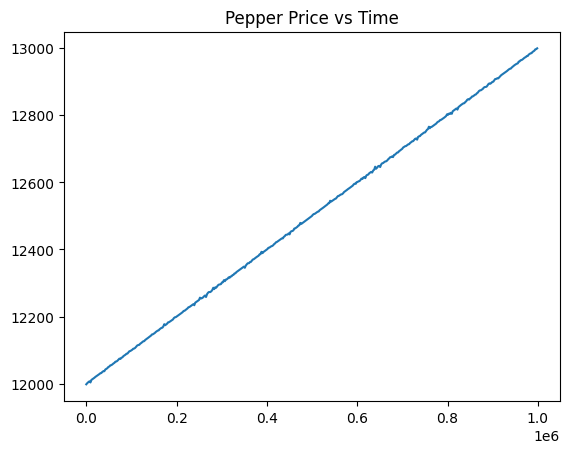

In [2]:
# plot 1 price vs time
plt.figure()
plt.plot(pepper_sampled["timestamp"], pepper_sampled["mid"])
plt.title("Pepper Price vs Time")
plt.show()


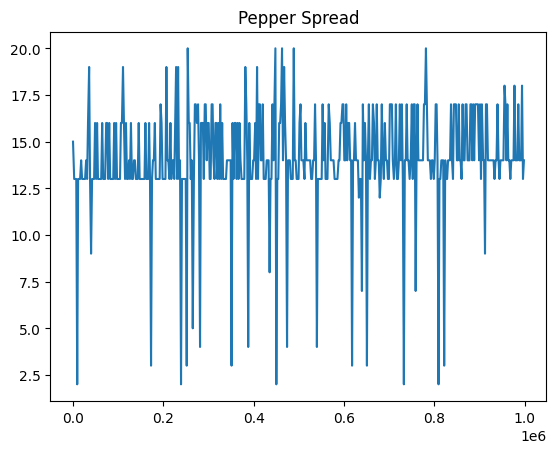

In [3]:
# plot 2 spread vs time
pepper["spread"] = pepper["ask_price_1"] - pepper["bid_price_1"]
pepper_sampled["spread"] = pepper_sampled["ask_price_1"] - pepper_sampled["bid_price_1"]

plt.figure()
# plt.plot(pepper["timestamp"], pepper["spread"])
plt.plot(pepper_sampled["timestamp"], pepper_sampled["spread"])
plt.title("Pepper Spread")
plt.show()


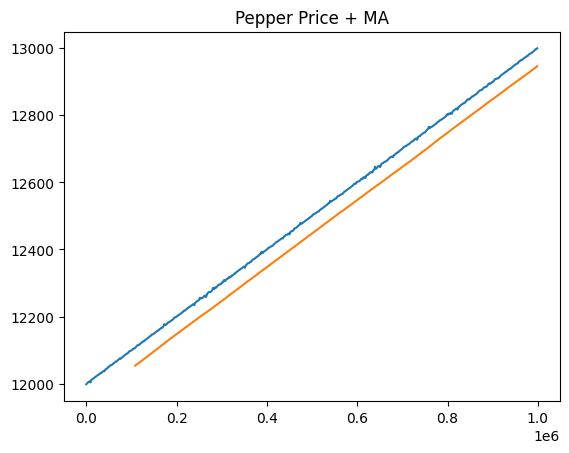

In [4]:
# plot 3 Moving Average
window = 50
pepper_sampled["ma"] = pepper_sampled["mid"].rolling(window).mean()
pepper["ma"] = pepper["mid"].rolling(window).mean()

plt.figure()
plt.plot(pepper_sampled["timestamp"], pepper_sampled["mid"])
plt.plot(pepper_sampled["timestamp"], pepper_sampled["ma"])
# plt.plot(pepper["timestamp"], pepper["mid"])
# plt.plot(pepper["timestamp"], pepper["ma"])
plt.title("Pepper Price + MA")
plt.show()

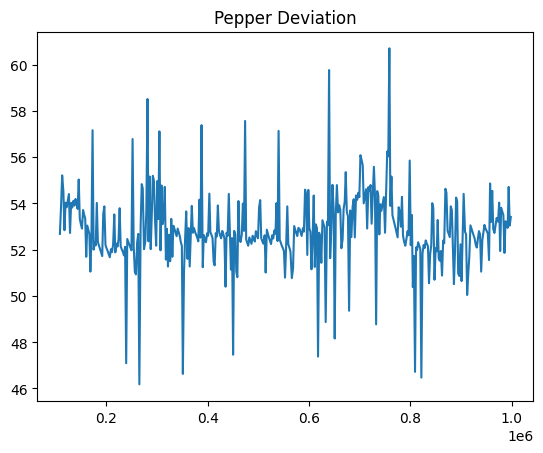

In [5]:
# plot 4 deviation
pepper["dev"] = pepper["mid"] - pepper["ma"]
pepper_sampled["dev"] = pepper_sampled["mid"] - pepper_sampled["ma"]

plt.figure()
plt.plot(pepper_sampled["timestamp"], pepper_sampled["dev"])
# plt.plot(pepper["timestamp"], pepper["dev"])
plt.title("Pepper Deviation")
plt.show()

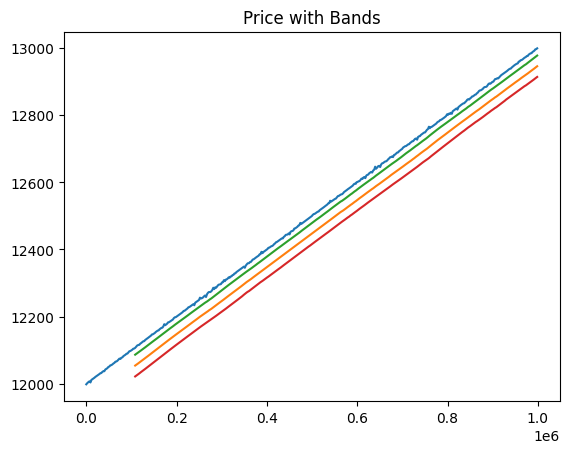

In [6]:
# trying something else
pepper_sampled["std"] = pepper_sampled["mid"].rolling(window).std()
pepper["std"] = pepper["mid"].rolling(window).std()

plt.figure()
plt.plot(pepper_sampled["timestamp"], pepper_sampled["mid"])
plt.plot(pepper_sampled["timestamp"], pepper_sampled["ma"])
plt.plot(pepper_sampled["timestamp"], pepper_sampled["ma"] + pepper_sampled["std"])
plt.plot(pepper_sampled["timestamp"], pepper_sampled["ma"] - pepper_sampled["std"])
plt.title("Price with Bands")
plt.show()

In [7]:
pepper["returns"] = pepper["mid"].diff()

print("Average drift per tick:", pepper["returns"].mean())
print("Deviation mean:", pepper["dev"].mean())
print("Deviation std:", pepper["dev"].std())
print("Deviation min:", pepper["dev"].min())
print("Deviation max:", pepper["dev"].max())
print("Average spread:", pepper["spread"].mean())

Average drift per tick: 0.10824686554258539
Deviation mean: 2.6461918730986507
Deviation std: 1.3264745863880483
Deviation min: -4.889999999999418
Deviation max: 9.889999999999418
Average spread: 14.128715011347671


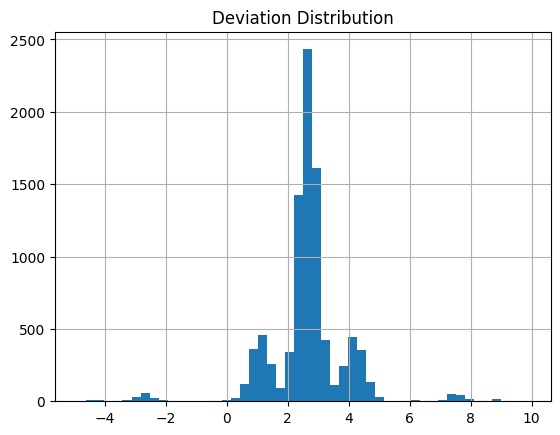

In [8]:
pepper["dev"].hist(bins=50)
plt.title("Deviation Distribution")
plt.show()